In [ ]:
import pandas as pd

# === 1. Upload file Excel/CSV ===
from google.colab import files
uploaded = files.upload()

# Baca file (ganti nama sesuai file yang diupload)
df = pd.read_excel('data hasil pertanyaan.xlsx')  # kalau CSV pakai pd.read_csv()

Saving data hasil pertanyaan.xlsx to data hasil pertanyaan (2).xlsx


In [ ]:
# === 2. Fungsi Cronbach's Alpha ===
def cronbach_alpha(df_items):
    k = df_items.shape[1]
    item_variances = df_items.var(axis=0, ddof=1)
    total_score = df_items.sum(axis=1)
    total_variance = total_score.var(ddof=1)
    return (k / (k - 1)) * (1 - (item_variances.sum() / total_variance))


In [ ]:
# === 3. Hitung Alpha total ===
alpha_total = cronbach_alpha(df)

In [ ]:
# === 4. Hitung Alpha jika tiap item dihapus ===
alphas_if_deleted = []
for col in df.columns:
    alpha = cronbach_alpha(df.drop(columns=[col]))
    alphas_if_deleted.append(alpha)

In [ ]:
# === 5. Fungsi interpretasi ===
def interpret_alpha(val):
    if val >= 0.9:
        return 'Sangat Tinggi'
    elif val >= 0.8:
        return 'Tinggi'
    elif val >= 0.7:
        return 'Cukup'
    else:
        return 'Rendah'

In [ ]:
# === 6. Buat DataFrame hasil ===
result_df = pd.DataFrame({
    'Item': df.columns,
    'Cronbach_Alpha_if_Deleted': alphas_if_deleted,
    'Interpretasi': [interpret_alpha(a) for a in alphas_if_deleted]
})

# Tambahkan baris total di atas
summary_row = pd.DataFrame({
    'Item': ['Total'],
    'Cronbach_Alpha_if_Deleted': [alpha_total],
    'Interpretasi': [interpret_alpha(alpha_total)]
})

final_df = pd.concat([summary_row, result_df], ignore_index=True)

In [ ]:
# === 7. Simpan ke Excel ===
output_filename = 'cronbach_alpha_detail.xlsx'
final_df.to_excel(output_filename, index=False)

In [ ]:
# === 8. Download file hasil ===
files.download(output_filename)

# Tampilkan hasil di Colab juga
final_df

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Item,Cronbach_Alpha_if_Deleted,Interpretasi
0,Total,0.969471,Sangat Tinggi
1,Q1,0.969156,Sangat Tinggi
2,Q2,0.969073,Sangat Tinggi
3,Q3,0.968421,Sangat Tinggi
4,Q4,0.967971,Sangat Tinggi
5,Q5,0.968736,Sangat Tinggi
6,Q6,0.968303,Sangat Tinggi
7,Q7,0.968070,Sangat Tinggi
8,Q8,0.968348,Sangat Tinggi
9,Q9,0.968832,Sangat Tinggi


Visual

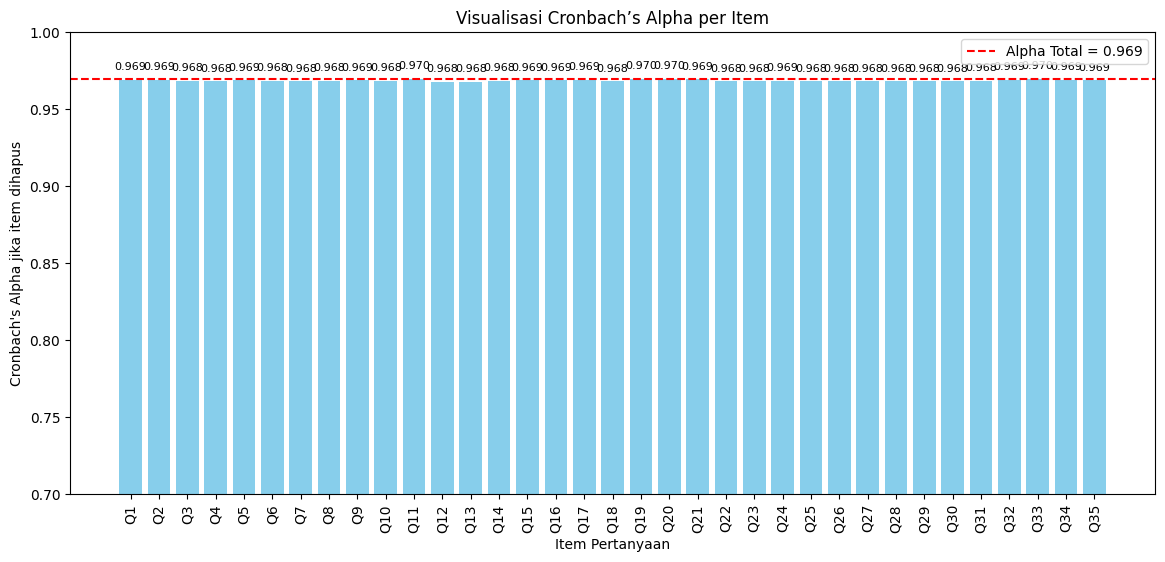

In [ ]:
import matplotlib.pyplot as plt

# Data dari tabel hasil sebelumnya
items = result_df['Item']
alphas = result_df['Cronbach_Alpha_if_Deleted']

plt.figure(figsize=(14,6))
bars = plt.bar(items, alphas, color='skyblue')

# Garis patokan Alpha total
plt.axhline(y=alpha_total, color='red', linestyle='--', label=f'Alpha Total = {alpha_total:.3f}')

# Label & judul
plt.xticks(rotation=90)
plt.ylim(0.7, 1.0)  # biar fokus di range relevan
plt.ylabel("Cronbach's Alpha jika item dihapus")
plt.xlabel("Item Pertanyaan")
plt.title("Visualisasi Cronbach’s Alpha per Item")
plt.legend()

# Tampilkan nilai di atas bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{bar.get_height():.3f}",
             ha='center', va='bottom', fontsize=8)

plt.show()


1. Kuesioner sangat konsisten
Nilai Alpha total = 0.969 → masuk kategori sangat tinggi.

Semua Alpha jika 1 item dihapus juga berada di kisaran yang sama (tidak ada yang jauh lebih tinggi atau rendah).

Artinya, responden menjawab semua pertanyaan dengan pola yang relatif seragam, dan setiap pertanyaan selaras dengan topik yang diukur.

2. Tidak ada pertanyaan “pengganggu”
Kalau ada pertanyaan yang tidak relevan atau ambigu, biasanya Alpha if Deleted akan naik signifikan dibanding Alpha total.

Di data kamu, tidak ada peningkatan berarti saat satu item dihapus → berarti tidak ada pertanyaan yang merusak konsistensi.

3. Kuesioner layak digunakan untuk analisis lanjut
Karena reliabilitas tinggi dan stabil, kamu aman untuk lanjut ke analisis deskriptif, regresi, atau uji lain tanpa khawatir bias dari instrumen yang tidak konsisten.

💡 Kesimpulan singkat untuk laporan:

Hasil uji reliabilitas menunjukkan nilai Cronbach’s Alpha sebesar 0.969 (sangat tinggi). Semua nilai Alpha jika satu item dihapus tetap tinggi dan tidak menunjukkan perbedaan signifikan, sehingga dapat disimpulkan bahwa seluruh item pertanyaan konsisten dan instrumen layak digunakan untuk penelitian.